# K-Means Clustering

In [1]:
import pandas as pd 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

Demo clustering with generate samples

c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


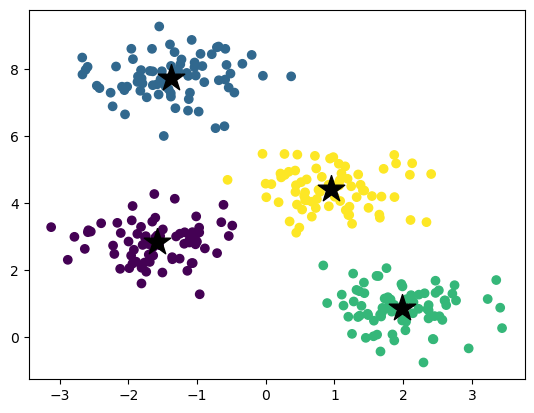

In [2]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=0)
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='*', s=400, color='black')
plt.show()

Loading actual data and clustering

In [4]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/customers.csv"

df = pd.read_csv(URL)
df.sample(5)

,Fresh_Food,Milk,Grocery,Frozen_Food
29,43088,2100,2609,1200
384,10683,21858,15400,3635
142,37036,7152,8253,2995
393,23632,6730,3842,8620
136,4625,8579,7030,4575


array([[<Axes: title={'center': 'Fresh_Food'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen_Food'}>]], dtype=object)

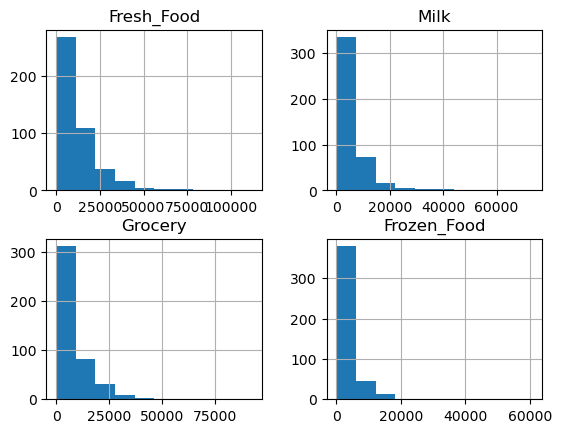

In [5]:
df.hist()

Now we create the clustering algorithm

In [15]:
number_of_clusters = 3
cluster = KMeans(n_clusters=number_of_clusters)
result = cluster.fit_transform(df)
cluster.cluster_centers_

c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([[7.55221944e+03, 3.90853605e+03, 5.49098746e+03, 2.53292476e+03,
        1.56739812e-01],
       [3.29398919e+04, 4.86736486e+03, 5.76856757e+03, 5.53852703e+03,
        1.02702703e+00],
       [9.22172340e+03, 2.00712553e+04, 2.80864468e+04, 2.84672340e+03,
        5.10638298e-01]])

Now we make predictions

In [16]:
df['cluster_number'] = cluster.predict(df)
df.sample(5)

,Fresh_Food,Milk,Grocery,Frozen_Food,cluster_number
128,140,8847,3823,142,0
274,894,1703,1841,744,0
55,5264,3683,5005,1057,0
135,6300,1289,2591,1170,0
353,117,6264,21203,228,0


Plotting our findings

c:\Users\dagim\miniconda3\envs\ml_lab\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


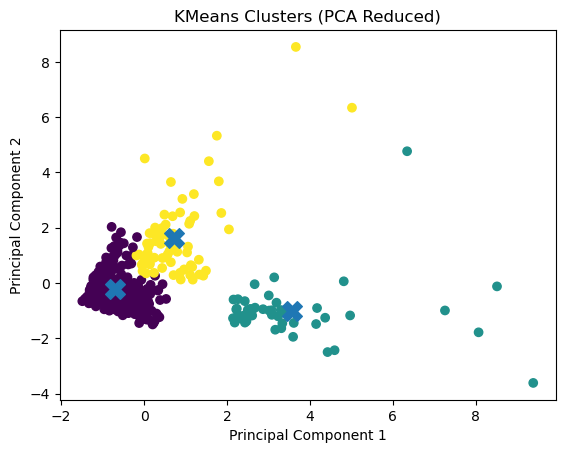

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 2. Apply KMeans 
number_of_clusters = 3
cluster = KMeans(n_clusters=number_of_clusters, random_state=42)
cluster.fit(scaled_data)

# Assign cluster labels
df['cluster_number'] = cluster.predict(scaled_data)

# 3. Reduce to 2D using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_data)

# Transform cluster centers to 2D as well
centers_2d = pca.transform(cluster.cluster_centers_)

# 4. Plot
plt.figure()

plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1],
    c=df['cluster_number']
)

# Plot cluster centers
plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker='X',
    s=200
)

plt.title('KMeans Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()
